**Logistic Regression:**


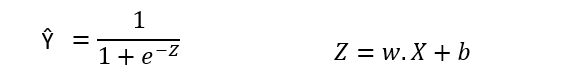

Y_hat --> predicted value

X --> Input Variable

w --> weight

b --> bias

**Gradient Descent:**

Gradient Descent is an optimization algorithm used for minimizing the loss function in various machine learning algorithms. It is used for updating the parameters of the learning model.

w  =  w - α*dw

b  =  b - α*db

**Learning Rate:**

Learning rate is a tuning parameter in an optimization algorithm that determines the step size at each iteration while moving toward a minimum of a loss function.

**Derivatives:**

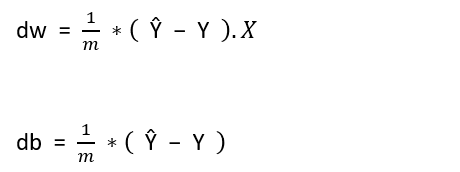

In [6]:
import numpy as np

In [7]:
class Logistic_Regression_from_Scratch():
  # declaring learning rate & number of iterations (Hyperparametes)
  def __init__(self, learning_rate = 0.001, no_of_iterations = 10000):
    self.learning_rate = learning_rate
    self.no_of_iterations = no_of_iterations

  # fit function to train the model with dataset
  def fit(self, X, y):
    # number of data points in the dataset (number of rows)  -->  m
    # number of input features in the dataset (number of columns)  --> n
    self.m, self.n = X.shape


    #initiating weight & bias value
    self.w = np.zeros(self.n)
    self.b = 0
    self.X = X
    self.y = y
    # implementing Gradient Descent for Optimization

    for i in range(self.no_of_iterations):
      self.update_weights()
      
  def update_weights(self):

    # y_hat formula (sigmoid function)
    
    y_hat = 1 / (1 + np.exp( - (self.X.dot(self.w) + self.b ) ))    
    
    # derivaties
    dw = (1/self.m)*np.dot(self.X.T, (y_hat - self.y))
    db = (1/self.m)*np.sum(y_hat - self.y)
    
    # updating the weights & bias using gradient descent
    
    self.w = self.w - self.learning_rate * dw
    self.b = self.b - self.learning_rate * db
    
  
  def predict(self, X):
    Y_pred = 1 / (1 + np.exp( - (X.dot(self.w) + self.b ) )) 
    Y_pred = np.where( Y_pred > 0.5, 1, 0)
    return Y_pred

In [20]:
from sklearn.datasets import load_breast_cancer
import pandas as pd

data = load_breast_cancer()

X = pd.DataFrame(data.data, columns=data.feature_names)
y = data.target

In [10]:
model_fs = Logistic_Regression_from_Scratch()

In [21]:
from sklearn.model_selection import train_test_split

X_train , X_test , y_train , y_test = train_test_split(X,y,test_size=0.20)

In [22]:
model_fs.fit(X_train,y_train)

d:\DATA SCIENCE\DS_Python\vnev_new\lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: overflow encountered in exp
  result = getattr(ufunc, method)(*inputs, **kwargs)
d:\DATA SCIENCE\DS_Python\vnev_new\lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: overflow encountered in exp
  result = getattr(ufunc, method)(*inputs, **kwargs)
d:\DATA SCIENCE\DS_Python\vnev_new\lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: overflow encountered in exp
  result = getattr(ufunc, method)(*inputs, **kwargs)
d:\DATA SCIENCE\DS_Python\vnev_new\lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: overflow encountered in exp
  result = getattr(ufunc, method)(*inputs, **kwargs)
d:\DATA SCIENCE\DS_Python\vnev_new\lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: overflow encountered in exp
  result = getattr(ufunc, method)(*inputs, **kwargs)
d:\DATA SCIENCE\DS_Python\vnev_new\lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: o

In [23]:
y_pred_fs = model_fs.predict(X_test)

d:\DATA SCIENCE\DS_Python\vnev_new\lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: overflow encountered in exp
  result = getattr(ufunc, method)(*inputs, **kwargs)


In [24]:
from sklearn.metrics import accuracy_score

print(accuracy_score(y_test,y_pred_fs))

0.9035087719298246


In [27]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=10000)

lr.fit(X_train,y_train)
y_pred_lr = lr.predict(X_test)

In [28]:
print(accuracy_score(y_test,y_pred_lr))

0.9298245614035088


In [30]:
print("*"*55)
print("accuracy_score for MY MODEL -> ",accuracy_score(y_test,y_pred_fs))
print("accuracy_score for SKLEARN MODEL -> ",accuracy_score(y_test,y_pred_lr))

*******************************************************
accuracy_score for MY MODEL ->  0.9035087719298246
accuracy_score for SKLEARN MODEL ->  0.9298245614035088


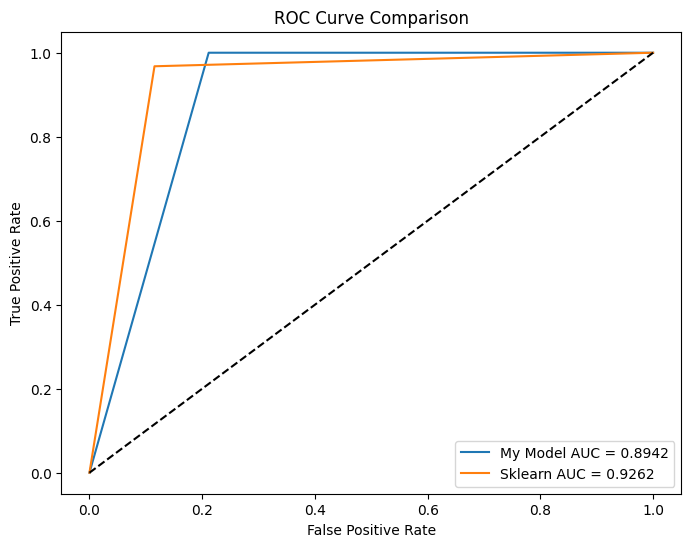

In [31]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt
# MODEL FROM SCRATCH
fpr1, tpr1, _ = roc_curve(y_test, y_pred_fs)
roc_auc1 = auc(fpr1, tpr1)

# SKLEARN MODEL
fpr2, tpr2, _ = roc_curve(y_test, y_pred_lr)
roc_auc2 = auc(fpr2, tpr2)

plt.figure(figsize=(8,6))

plt.plot(fpr1, tpr1,
         label=f'My Model AUC = {roc_auc1:.4f}')

plt.plot(fpr2, tpr2,
         label=f'Sklearn AUC = {roc_auc2:.4f}')

plt.plot([0,1],[0,1],'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")

plt.legend()
plt.show()